# Analysing Training Data Amount Effect

In [ ]:
%%capture
# Run to set environment variables if want to
# %env HF_TOKEN=

In [ ]:
%%capture
import os
# If getting 'Could not find project LASR_probe_gen' get key from https://wandb.ai/authorize and paste below
os.environ["WANDB_SILENT"] = "true"
os.environ["WANDB_API_KEY"] = ""
import wandb
wandb_token = os.getenv("WANDB_API_KEY")
wandb.login(key=wandb_token)

## Do probe training

0.6327439999999999
Subset size 100 → ROC-AUC: 0.633
0.724852
Subset size 200 → ROC-AUC: 0.725
0.749992
Subset size 300 → ROC-AUC: 0.750
0.7771999999999999
Subset size 400 → ROC-AUC: 0.777
0.818212
Subset size 500 → ROC-AUC: 0.818
0.830872
Subset size 600 → ROC-AUC: 0.831
0.861456
Subset size 700 → ROC-AUC: 0.861
0.8775
Subset size 800 → ROC-AUC: 0.877
0.8849039999999999
Subset size 900 → ROC-AUC: 0.885
0.911096
Subset size 1000 → ROC-AUC: 0.911
0.9001680000000001
Subset size 1100 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1200 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1300 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1400 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1500 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1600 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1700 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1800 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1900 → ROC-AUC: 0.900
0.9001680000000001
Subset size 2000 → ROC-AUC: 0.900
0.9001680000000001
Su

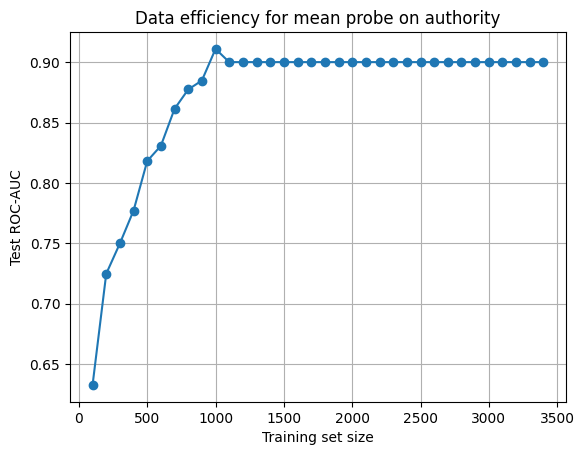

In [ ]:
# Balanced data, increasing positives and negatives

import probe_gen.probes as probes
from sklearn.metrics import classification_report
from probe_gen.config import ConfigDict
    
import torch
import numpy as np
from sklearn.utils import shuffle

probe_type = ["mean", "attention_torch"][0]
behaviour = "authority"
datasource = "arguments"
activations_model = "llama_3b"
generation_method = "off_policy"
response_model = "llama_3b"
off_policy_model = "qwen_7b"
mode = "train"

# Load the best hyperparameters or set your own
dataset_name = None
cfg = ConfigDict.from_json(activations_model, probe_type, behaviour)

# Create train, val, and test datasets
used_model = response_model if generation_method != "off_policy" else off_policy_model
activations_tensor, attention_mask, labels_tensor = probes.load_hf_activations_at_layer(
    behaviour, datasource, activations_model, used_model, generation_method, mode, cfg.layer, and_labels=True)
if "mean" in probe_type:
    activations_tensor = probes.MeanAggregation()(activations_tensor, attention_mask)

# Eval against seperate test datasets
test_generation_method = "on_policy"
used_model = response_model if test_generation_method != "off_policy" else off_policy_model
activations_tensor, attention_mask, labels_tensor = probes.load_hf_activations_at_layer(
    behaviour, datasource, activations_model, used_model, test_generation_method, "test", cfg.layer, and_labels=True)
if "mean" in probe_type:
    activations_tensor = probes.MeanAggregation()(activations_tensor, attention_mask)
_, _, test_dataset = probes.create_activation_datasets(
    activations_tensor, labels_tensor, splits=[0, 0, 1000])

# Define subset sizes to test (must be even)
subset_sizes = list(range(100,3500,100))

# Split indices by class
pos_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]
neg_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]

results = {}

for n in subset_sizes:
    half = n // 2
    # Randomly sample equal numbers from each class
    pos_sample = pos_indices[torch.randperm(len(pos_indices))[:half]]
    neg_sample = neg_indices[torch.randperm(len(neg_indices))[:half]]
    subset_idx = torch.cat([pos_sample, neg_sample])
    subset_idx = subset_idx[torch.randperm(len(subset_idx))]  # shuffle order

    # Select activations and labels
    activ_subset = activations_tensor[subset_idx]
    label_subset = labels_tensor[subset_idx]

    # Create datasets (e.g., 80% train, 20% val)
    n_train = int(0.8 * len(label_subset))
    n_val = len(label_subset) - n_train
    train_dataset, val_dataset, _ = probes.create_activation_datasets(
        activ_subset, label_subset, splits=[n_train, n_val, 0]
    )

    # Initialise and train probe
    if probe_type == "mean":
        probe = probes.SklearnLogisticProbe(cfg)
    elif probe_type == "mean_torch":
        probe = probes.TorchLinearProbe(cfg)
    elif probe_type == "attention_torch":
        probe = probes.TorchAttentionProbe(cfg)

    probe.fit(train_dataset, val_dataset)

    # Evaluate the model
    eval_dict, _, _ = probe.eval(test_dataset)
    print(eval_dict['roc_auc'])

    # Evaluate on the *same test set* you already prepared
    eval_dict, _, _ = probe.eval(test_dataset)
    results[n] = eval_dict["roc_auc"]

    print(f"Subset size {n} → ROC-AUC: {eval_dict['roc_auc']:.3f}")

# print("\nFinal results:", results)


import matplotlib.pyplot as plt

plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Training set size")
plt.ylabel("Test ROC-AUC")
plt.title(f"Data efficiency for {probe_type} probe on {behaviour}")
plt.grid(True)
plt.show()


0.680948
Subset size 100 → ROC-AUC: 0.681
0.7279880000000001
Subset size 200 → ROC-AUC: 0.728
0.7836879999999999
Subset size 300 → ROC-AUC: 0.784
0.7937799999999999
Subset size 400 → ROC-AUC: 0.794
0.8382839999999999
Subset size 500 → ROC-AUC: 0.838
0.8617440000000001
Subset size 600 → ROC-AUC: 0.862
0.877316
Subset size 700 → ROC-AUC: 0.877
0.889832
Subset size 800 → ROC-AUC: 0.890
0.88868
Subset size 900 → ROC-AUC: 0.889
0.911096
Subset size 1000 → ROC-AUC: 0.911
0.9001680000000001
Subset size 1100 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1200 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1300 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1400 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1500 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1600 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1700 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1800 → ROC-AUC: 0.900
0.9001680000000001
Subset size 1900 → ROC-AUC: 0.900
0.9001680000000001
Subset size 2000 → ROC-AUC: 0.900


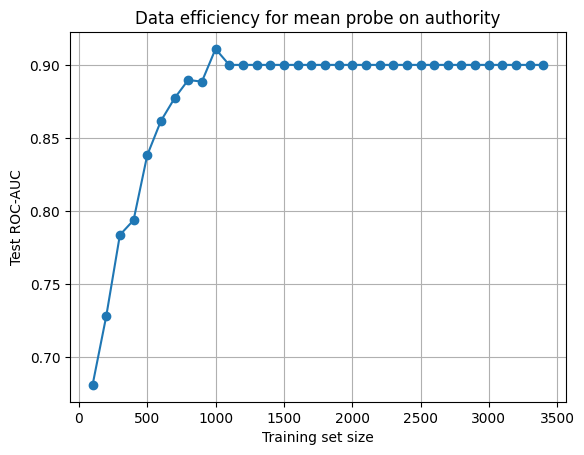

In [17]:
# Unbalanced data, 1000 positives, increasing negatives only

import probe_gen.probes as probes
from sklearn.metrics import classification_report
from probe_gen.config import ConfigDict
    
import torch
import numpy as np
from sklearn.utils import shuffle

probe_type = ["mean", "attention_torch"][0]
behaviour = "authority"
datasource = "arguments"
activations_model = "llama_3b"
generation_method = "off_policy"
response_model = "llama_3b"
off_policy_model = "qwen_7b"
mode = "train"

# Load the best hyperparameters or set your own
dataset_name = None
cfg = ConfigDict.from_json(activations_model, probe_type, behaviour)

# Create train, val, and test datasets
used_model = response_model if generation_method != "off_policy" else off_policy_model
activations_tensor, attention_mask, labels_tensor = probes.load_hf_activations_at_layer(
    behaviour, datasource, activations_model, used_model, generation_method, mode, cfg.layer, and_labels=True)
if "mean" in probe_type:
    activations_tensor = probes.MeanAggregation()(activations_tensor, attention_mask)

# Eval against seperate test datasets
test_generation_method = "on_policy"
used_model = response_model if test_generation_method != "off_policy" else off_policy_model
activations_tensor, attention_mask, labels_tensor = probes.load_hf_activations_at_layer(
    behaviour, datasource, activations_model, used_model, test_generation_method, "test", cfg.layer, and_labels=True)
if "mean" in probe_type:
    activations_tensor = probes.MeanAggregation()(activations_tensor, attention_mask)
_, _, test_dataset = probes.create_activation_datasets(
    activations_tensor, labels_tensor, splits=[0, 0, 1000])

# Define subset sizes to test (must be even)
subset_sizes = list(range(100,3500,100))

# Split indices by class
pos_indices = (labels_tensor == 1).nonzero(as_tuple=True)[0]
neg_indices = (labels_tensor == 0).nonzero(as_tuple=True)[0]

results = {}

for n in subset_sizes:
    half = n // 2
    # Randomly sample equal numbers from each class
    pos_sample = pos_indices[torch.randperm(len(pos_indices))[:1000]]
    neg_sample = neg_indices[torch.randperm(len(neg_indices))[:half]]
    subset_idx = torch.cat([pos_sample, neg_sample])
    subset_idx = subset_idx[torch.randperm(len(subset_idx))]  # shuffle order

    # Select activations and labels
    activ_subset = activations_tensor[subset_idx]
    label_subset = labels_tensor[subset_idx]

    # Create datasets (e.g., 80% train, 20% val)
    n_train = int(0.8 * len(label_subset))
    n_val = len(label_subset) - n_train
    train_dataset, val_dataset, _ = probes.create_activation_datasets(
        activ_subset, label_subset, splits=[n_train, n_val, 0]
    )

    # Initialise and train probe
    if probe_type == "mean":
        probe = probes.SklearnLogisticProbe(cfg)
    elif probe_type == "mean_torch":
        probe = probes.TorchLinearProbe(cfg)
    elif probe_type == "attention_torch":
        probe = probes.TorchAttentionProbe(cfg)

    probe.fit(train_dataset, val_dataset)

    # Evaluate the model
    eval_dict, _, _ = probe.eval(test_dataset)
    print(eval_dict['roc_auc'])

    # Evaluate on the *same test set* you already prepared
    eval_dict, _, _ = probe.eval(test_dataset)
    results[n] = eval_dict["roc_auc"]

    print(f"Subset size {n} → ROC-AUC: {eval_dict['roc_auc']:.3f}")

# print("\nFinal results:", results)


import matplotlib.pyplot as plt

plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Training set size")
plt.ylabel("Test ROC-AUC")
plt.title(f"Data efficiency for {probe_type} probe on {behaviour}")
plt.grid(True)
plt.show()
